<a href="https://colab.research.google.com/github/Finney04S/Final-Year-Project/blob/main/Final_Year_Project_PG_TabNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas numpy scikit-learn matplotlib pytorch-tabnet torch optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 12.0 MB/s eta 0:00:00


In [ ]:
# Install required packages (run once)
!pip install -q pytorch-tabnet==0.3.1 torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q scikit-learn pandas matplotlib optuna
# Note: Colab may already have torch; the command above ensures compatible versions.

ERROR: Could not find a version that satisfies the requirement pytorch-tabnet==0.3.1 (from versions: none)
ERROR: No matching distribution found for pytorch-tabnet==0.3.1


In [ ]:
import os, math, random, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch
np.random.seed(42); random.seed(42); torch.manual_seed(42)
print("Torch:", torch.__version__)

Torch: 2.9.0+cpu


In [ ]:
# Generates an enhanced physics-consistent synthetic dataset (n rows).
# Increase n for better training (but longer runtime).
def generate_enhanced_dataset(out_path="EV_Physics_Enhanced_Dataset_v3.csv", n=2000, seed=2025):
    np.random.seed(seed)
    # Trip splits
    trip_lengths = []
    remaining = n
    while remaining>0:
        l = np.random.randint(50, 200)
        l = min(l, remaining)
        trip_lengths.append(l)
        remaining -= l
    trip_id = []
    for i,l in enumerate(trip_lengths):
        trip_id += [f"trip_{i+1}"]*l
    trip_id = np.array(trip_id)

    Speed_kmh = np.clip(np.random.normal(45,20,n), 0, 130).round(2)
    Acceleration_ms2 = np.clip(np.random.normal(0,1.2,n), -4, 4).round(3)
    Slope_pct = np.clip(np.random.normal(0.5,2.0,n), -10, 12).round(2)
    Distance_Travelled_km = np.clip(Speed_kmh/60 + np.random.normal(0,0.02,n), 0.01, 2.0).round(3)
    Vehicle_Weight_kg = np.random.choice([1500,1600,1700,1800,1900], n)
    Payload_kg = np.round(np.random.choice([0,50,100,150,200], n, p=[0.4,0.2,0.2,0.15,0.05]),1)
    Battery_Temperature_C = np.clip(np.random.normal(25,5,n), -10,50).round(2)
    Weather_Condition = np.random.choice(['Clear','Rain','Cloudy','Snow','Fog'], n, p=[0.6,0.15,0.15,0.03,0.07])
    Traffic_Condition = np.random.choice(['Free','Light','Moderate','Heavy','Standstill'], n, p=[0.3,0.35,0.25,0.08,0.02])
    Driving_Mode = np.where(Speed_kmh>80,'Sport', np.where(Speed_kmh<30,'Eco','Normal'))
    Road_Type = np.where(Slope_pct>3,'Hilly','Urban')

    # Physics
    g=9.81; Cr=0.015; rho=1.225; Cd=0.29; A=2.3; eff=0.92; drivetrain_loss=1.08
    v_ms = Speed_kmh / 3.6
    m = Vehicle_Weight_kg + Payload_kg
    a = Acceleration_ms2
    theta = np.arctan(Slope_pct/100.0)
    F_acc = m * a
    F_climb = m * g * np.sin(theta)
    F_roll = Cr * m * g * np.cos(theta)
    F_drag = 0.5 * rho * Cd * A * (v_ms**2)
    F_resistive = F_acc + F_climb + F_roll + F_drag
    P_load_W = v_ms * F_resistive
    P_load_kW = (P_load_W / 1000.0) / eff
    Theoretical_Power_Demand = np.round(np.clip(P_load_kW, -50, 300), 4)
    safe_speed = np.clip(Speed_kmh, 1.0, None)
    time_h = Distance_Travelled_km / safe_speed
    Theoretical_Energy_kWh = np.round((Theoretical_Power_Demand * time_h * drivetrain_loss).clip(0,100), 4)

    # Digital twin maps
    wheel_radius_m = 0.33; gear_ratio = 8.5
    Motor_RPM = np.round((v_ms / (2*np.pi*wheel_radius_m)) * 60 * gear_ratio).clip(500,12000)
    omega = (Motor_RPM * 2 * np.pi) / 60.0
    Motor_Torque_Nm = np.round(np.clip((P_load_W / (omega + 1e-9)), -200, 500), 1)
    motor_eff = 0.75 + 0.2 * np.exp(-((Motor_RPM-3000)/2500.0)**2) + 0.06 * np.tanh(np.clip(Motor_Torque_Nm,0,300)/150.0)
    motor_eff = np.clip(motor_eff, 0.6, 0.98).round(3)

    # SOC per trip
    battery_capacity_kWh = 60.0
    soc = np.zeros(n)
    start_idx = 0
    for l in trip_lengths:
        soc_val = np.random.uniform(60,100)
        end_idx = start_idx + l
        energy = Theoretical_Energy_kWh[start_idx:end_idx]
        energy_share = energy * (1 + np.random.normal(0,0.05,size=l))
        soc_segment = soc_val - (np.cumsum(energy_share) / battery_capacity_kWh * 100.0)
        soc[start_idx:end_idx] = np.clip(soc_segment, 5, 100)
        start_idx = end_idx
    State_of_Charge_pct = np.round(soc,2)

    Battery_Voltage_V = np.round(np.clip(350 + 0.45*(Battery_Temperature_C-25) + 0.25*(State_of_Charge_pct-50) + np.random.normal(0,2,n), 320,420),1)
    I = P_load_W / (Battery_Voltage_V + 1e-9)
    regen_mask = Acceleration_ms2 < -0.2
    I_regen = -0.6 * np.abs(I) * (np.minimum(1.0, np.abs(Acceleration_ms2)/3.0))
    Battery_Current_A = np.round(np.where(regen_mask, I_regen, I),1)
    Battery_Current_A = np.clip(Battery_Current_A, -400, 700)
    Regen_Energy_kWh = np.round(np.where(Battery_Current_A<0, (-Battery_Current_A*Battery_Voltage_V)/1000.0 * time_h, 0.0),4)

    # Actual energy from refined physics + noise
    E_refined = Theoretical_Energy_kWh / (motor_eff * (0.95 + 0.05*np.tanh((State_of_Charge_pct-30)/30)))
    Energy_Consumption_kWh = np.round(np.clip(E_refined - 0.6*Regen_Energy_kWh + np.random.normal(0,0.02,n), 0.0, 200.0),4)

    Wind_Speed_mps = np.round(np.abs(np.random.normal(2.5 + 0.5*(Weather_Condition=='Rain'), 1.2, n)).clip(0,12),2)
    Tire_Pressure_PSI = np.round(np.random.uniform(30,36,n),1)
    GPS_Elevation_m = np.round(np.clip(np.cumsum((Slope_pct/100.0) * Distance_Travelled_km *1000.0) % 2000, 0, 3000),1)

    # Timestamps (30s segments) and driver id
    timestamps = []
    start_time = pd.Timestamp("2025-01-01 08:00:00")
    for l in trip_lengths:
        for s in range(l):
            timestamps.append(start_time + pd.Timedelta(seconds=30*s))
        start_time += pd.Timedelta(minutes=5) + pd.Timedelta(seconds=30*l)
    Driver_ID = np.random.choice([f"Driver_{i}" for i in range(1,21)], n)

    df = pd.DataFrame({
        'Timestamp': timestamps[:n],
        'Trip_ID': trip_id[:n],
        'Driver_ID': Driver_ID,
        'Speed_kmh': Speed_kmh,
        'Acceleration_ms2': Acceleration_ms2,
        'Slope_%': Slope_pct,
        'Distance_Travelled_km': Distance_Travelled_km,
        'Vehicle_Weight_kg': Vehicle_Weight_kg,
        'Payload_kg': Payload_kg,
        'Battery_Temperature_C': Battery_Temperature_C,
        'Weather_Condition': Weather_Condition,
        'Traffic_Condition': Traffic_Condition,
        'Driving_Mode': Driving_Mode,
        'Road_Type': Road_Type,
        'Wind_Speed_mps': Wind_Speed_mps,
        'Tire_Pressure_PSI': Tire_Pressure_PSI,
        'GPS_Elevation_m': GPS_Elevation_m,
        'State_of_Charge_pct': State_of_Charge_pct,
        'Motor_RPM': Motor_RPM,
        'Motor_Torque_Nm': Motor_Torque_Nm,
        'Motor_Efficiency': motor_eff,
        'Battery_Voltage_V': Battery_Voltage_V,
        'Battery_Current_A': Battery_Current_A,
        'Regen_Energy_kWh': Regen_Energy_kWh,
        'Theoretical_Power_Demand': Theoretical_Power_Demand,
        'Theoretical_Energy_kWh': Theoretical_Energy_kWh,
        'Energy_Consumption_kWh': Energy_Consumption_kWh
    })
    df.to_csv(out_path, index=False)
    print(f"Saved enhanced dataset to: {out_path}")
    return df

# Generate dataset (change n if you want larger)
df = generate_enhanced_dataset(out_path="EV_Physics_Enhanced_Dataset_v3.csv", n=2000)
df.head()


Saved enhanced dataset to: EV_Physics_Enhanced_Dataset_v3.csv


,Timestamp,Trip_ID,Driver_ID,Speed_kmh,Acceleration_ms2,Slope_%,Distance_Travelled_km,Vehicle_Weight_kg,Payload_kg,Battery_Temperature_C,...,State_of_Charge_pct,Motor_RPM,Motor_Torque_Nm,Motor_Efficiency,Battery_Voltage_V,Battery_Current_A,Regen_Energy_kWh,Theoretical_Power_Demand,Theoretical_Energy_kWh,Energy_Consumption_kWh
0,2025-01-01 08:00:00,trip_1,Driver_12,40.00,-0.441,1.25,0.683,1600,0,21.49,...,97.59,2733.0,-8.7,0.948,359.4,-0.6,0.0037,-2.7000,0.0000,0.0000
1,2025-01-01 08:00:30,trip_1,Driver_8,32.22,0.781,4.34,0.523,1700,50,18.58,...,96.86,2201.0,93.2,0.964,360.4,59.6,0.0000,23.3587,0.4095,0.4266
2,2025-01-01 08:01:00,trip_1,Driver_8,38.28,1.196,0.82,0.628,1800,0,20.30,...,96.00,2615.0,101.3,0.980,356.4,77.8,0.0000,30.1506,0.5342,0.5482
3,2025-01-01 08:01:30,trip_1,Driver_4,48.71,0.898,4.97,0.802,1800,100,29.70,...,94.67,3328.0,115.9,0.980,359.5,112.4,0.0000,43.9074,0.7808,0.8055
4,2025-01-01 08:02:00,trip_1,Driver_11,60.72,-0.092,-2.84,0.992,1900,50,25.75,...,94.67,4149.0,-12.4,0.912,362.0,-14.9,0.0881,-5.8558,0.0000,0.0000


In [ ]:
# show some stats
print(df.describe().round(3).T[['mean','std','min','max']].head(12))
print("\nColumns:", df.columns.tolist())

                                                mean      std  \
Timestamp              2025-01-01 16:56:58.499999744      NaN   
Speed_kmh                                     44.609   19.818   
Acceleration_ms2                               0.012    1.207   
Slope_%                                        0.561    1.954   
Distance_Travelled_km                          0.745     0.33   
Vehicle_Weight_kg                             1707.4  142.918   
Payload_kg                                    61.125     61.7   
Battery_Temperature_C                          24.97     4.94   
Wind_Speed_mps                                 2.573    1.184   
Tire_Pressure_PSI                              32.97    1.716   
GPS_Elevation_m                              899.911  586.573   
State_of_Charge_pct                           49.795   24.357   

                                       min                  max  
Timestamp              2025-01-01 08:00:00  2025-01-02 01:54:30  
Speed_kmh             

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")



🚀 Training BASIC TabNet...
epoch 0  | loss: 1.8702  | val_0_residual_rmse: 1.3575  |  0:00:00s
epoch 1  | loss: 0.60819 | val_0_residual_rmse: 0.96509 |  0:00:00s
epoch 2  | loss: 0.50135 | val_0_residual_rmse: 0.87975 |  0:00:01s
epoch 3  | loss: 0.38946 | val_0_residual_rmse: 0.65159 |  0:00:01s
epoch 4  | loss: 0.41605 | val_0_residual_rmse: 0.5844  |  0:00:01s
epoch 5  | loss: 0.32025 | val_0_residual_rmse: 0.71019 |  0:00:02s
epoch 6  | loss: 0.28404 | val_0_residual_rmse: 0.57133 |  0:00:02s
epoch 7  | loss: 0.28723 | val_0_residual_rmse: 0.762   |  0:00:02s
epoch 8  | loss: 0.32304 | val_0_residual_rmse: 0.63924 |  0:00:03s
epoch 9  | loss: 0.2614  | val_0_residual_rmse: 0.79772 |  0:00:03s
epoch 10 | loss: 0.25908 | val_0_residual_rmse: 0.77561 |  0:00:04s
epoch 11 | loss: 0.2328  | val_0_residual_rmse: 0.48442 |  0:00:04s
epoch 12 | loss: 0.25286 | val_0_residual_rmse: 0.43099 |  0:00:05s
epoch 13 | loss: 0.23035 | val_0_residual_rmse: 0.41406 |  0:00:05s
epoch 14 | loss: 0.2

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 3.18512 | val_0_residual_rmse: 1.5961  |  0:00:00s
epoch 1  | loss: 1.00976 | val_0_residual_rmse: 0.85054 |  0:00:00s
epoch 2  | loss: 0.71876 | val_0_residual_rmse: 0.9298  |  0:00:01s
epoch 3  | loss: 0.51041 | val_0_residual_rmse: 0.77107 |  0:00:01s
epoch 4  | loss: 0.47527 | val_0_residual_rmse: 0.85357 |  0:00:02s
epoch 5  | loss: 0.42524 | val_0_residual_rmse: 0.62103 |  0:00:02s
epoch 6  | loss: 0.32779 | val_0_residual_rmse: 0.57436 |  0:00:03s
epoch 7  | loss: 0.26744 | val_0_residual_rmse: 0.49633 |  0:00:03s
epoch 8  | loss: 0.28837 | val_0_residual_rmse: 0.53743 |  0:00:04s
epoch 9  | loss: 0.2854  | val_0_residual_rmse: 0.64736 |  0:00:04s
epoch 10 | loss: 0.26223 | val_0_residual_rmse: 0.54248 |  0:00:05s
epoch 11 | loss: 0.27457 | val_0_residual_rmse: 0.6045  |  0:00:05s
epoch 12 | loss: 0.27458 | val_0_residual_rmse: 0.58769 |  0:00:06s
epoch 13 | loss: 0.27427 | val_0_residual_rmse: 0.65084 |  0:00:06s
epoch 14 | loss: 0.27597 | val_0_residual_rmse: 

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



📊 FINAL MODEL COMPARISON
[Basic TabNet] RMSE: 0.023246259719925326 | R2: 0.9977107236067783
[Proposed PG-TabNet] RMSE: 0.019433858109056682 | R2: 0.9984000363585103


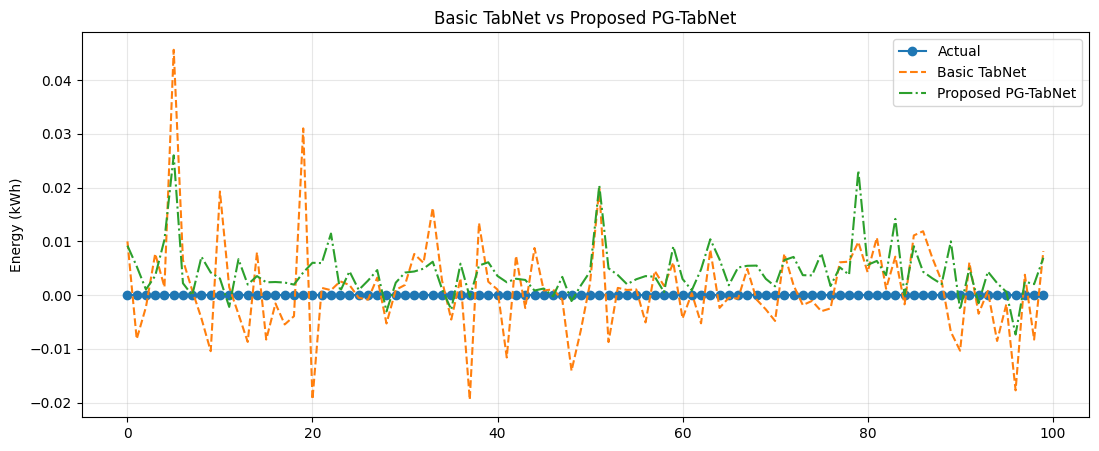

In [ ]:
# ============================================================
# BASIC TABNET vs PROPOSED PG-TABNET (FAST MODE)
# ============================================================

import numpy as np
import pandas as pd
import torch
from pytorch_tabnet.tab_model import TabNetRegressor
from pytorch_tabnet.metrics import Metric
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ================================
# SETTINGS
# ================================
DATA_PATH = "EV_Physics_Enhanced_Dataset_v3.csv"
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

MAX_EPOCHS = 80
PATIENCE = 20
BATCH_SIZE = 128
VIRTUAL_BATCH = 64
TEST_SIZE = 0.2

# Physics-guided tuning (PG-TabNet advantage)
LAMBDA_PHYSICS = 0.002
SOC_WEIGHT = 0.2

# ================================
# LOAD DATA
# ================================
df = pd.read_csv(DATA_PATH, parse_dates=['Timestamp'])

# ================================
# FEATURE SELECTION
# ================================
num_cols = [
    'Speed_kmh','Acceleration_ms2','Slope_%','Distance_Travelled_km',
    'Vehicle_Weight_kg','Payload_kg','Battery_Temperature_C',
    'Motor_RPM','Motor_Torque_Nm','Battery_Voltage_V',
    'Battery_Current_A','Regen_Energy_kWh',
    'Theoretical_Power_Demand','Theoretical_Energy_kWh'
]
num_cols = [c for c in num_cols if c in df.columns]

cat_cols = ['Weather_Condition','Traffic_Condition','Driving_Mode','Road_Type']
cat_cols = [c for c in cat_cols if c in df.columns]

# ================================
# ENCODE CATEGORICAL FEATURES
# ================================
for c in cat_cols:
    df[c] = LabelEncoder().fit_transform(df[c].astype(str))

# ================================
# TARGET ENGINEERING
# ================================
df['Energy_Residual_kWh'] = df['Energy_Consumption_kWh'] - df['Theoretical_Energy_kWh']
df['SOC_Drop_pct'] = (df['Energy_Consumption_kWh'] / 60.0) * 100.0

# ================================
# INPUT MATRICES
# ================================
X = df[num_cols + cat_cols].values
y_res = df['Energy_Residual_kWh'].values.reshape(-1,1)
y_soc = df['SOC_Drop_pct'].values.reshape(-1,1)

# ================================
# TRAIN / TEST SPLIT (INDEX SAFE)
# ================================
idx_all = np.arange(len(df))
train_idx, test_idx = train_test_split(idx_all, test_size=TEST_SIZE, random_state=SEED)

X_train = X[train_idx]
X_test  = X[test_idx]

y_res_train = y_res[train_idx]
y_res_test  = y_res[test_idx]

y_soc_train = y_soc[train_idx]
y_soc_test  = y_soc[test_idx]

theo_test = df.iloc[test_idx]['Theoretical_Energy_kWh'].values.reshape(-1,1)
actual_test = df.iloc[test_idx]['Energy_Consumption_kWh'].values.reshape(-1,1)

# ================================
# SCALING
# ================================
scaler_X = StandardScaler()
X_train[:, :len(num_cols)] = scaler_X.fit_transform(X_train[:, :len(num_cols)])
X_test[:, :len(num_cols)] = scaler_X.transform(X_test[:, :len(num_cols)])

res_scaler = StandardScaler()
soc_scaler = StandardScaler()

y_res_train_s = res_scaler.fit_transform(y_res_train)
y_res_test_s = res_scaler.transform(y_res_test)

y_soc_train_s = soc_scaler.fit_transform(y_soc_train)
y_soc_test_s = soc_scaler.transform(y_soc_test)

# Targets
y_train_pg = np.hstack([y_res_train_s, y_soc_train_s])
y_test_pg  = np.hstack([y_res_test_s,  y_soc_test_s])

# ================================
# CATEGORICAL INDEXING
# ================================
cat_idxs = list(range(len(num_cols), len(num_cols) + len(cat_cols)))
cat_dims = [df[c].nunique() for c in cat_cols]

# ================================
# METRIC
# ================================
class ResidualRMSE(Metric):
    def __init__(self):
        self._name = "residual_rmse"
        self._maximize = False
    def __call__(self, y_true, y_score):
        return np.sqrt(mean_squared_error(y_true[:,0], y_score[:,0]))

# ================================
# PHYSICS-GUIDED LOSS (FAST)
# ================================
class FastPhysicsGuidedLoss(torch.nn.Module):
    def __init__(self, lambda_reg=LAMBDA_PHYSICS, soc_weight=SOC_WEIGHT):
        super().__init__()
        self.lambda_reg = lambda_reg
        self.soc_weight = soc_weight
        self.mse = torch.nn.MSELoss()

    def forward(self, y_pred, y_true):
        res_pred = y_pred[:,0]
        soc_pred = y_pred[:,1]
        res_true = y_true[:,0]
        soc_true = y_true[:,1]

        data_loss = self.mse(res_pred, res_true)
        physics_loss = self.mse(res_pred, torch.zeros_like(res_pred))
        soc_loss = self.mse(soc_pred, soc_true)

        return data_loss + self.lambda_reg*physics_loss + self.soc_weight*soc_loss

# ================================
# BASIC TABNET (BASELINE)
# ================================
basic_tabnet = TabNetRegressor(
    n_d=16,
    n_a=16,
    n_steps=3,
    gamma=1.3,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.01),
    verbose=1
)

print("\n🚀 Training BASIC TabNet...")
basic_tabnet.fit(
    X_train=X_train,
    y_train=y_res_train_s,
    eval_set=[(X_test, y_res_test_s)],
    eval_metric=[ResidualRMSE],
    max_epochs=60,
    patience=15,
    batch_size=BATCH_SIZE,
    virtual_batch_size=VIRTUAL_BATCH
)

basic_residual = res_scaler.inverse_transform(basic_tabnet.predict(X_test))
basic_energy_pred = theo_test + basic_residual

# ================================
# PROPOSED PG-TABNET (FAST MODE)
# ================================
pg_tabnet = TabNetRegressor(
    n_d=32,      # ↑ from 24
    n_a=32,      # ↑ from 24
    n_steps=4,
    gamma=1.5,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=0.01),
    scheduler_params={"step_size":25, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    verbose=1
)

print("\n🚀 Training PROPOSED PG-TabNet...")
pg_tabnet.fit(
    X_train=X_train,
    y_train=y_train_pg,
    eval_set=[(X_test, y_test_pg)],
    eval_metric=[ResidualRMSE],
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    batch_size=BATCH_SIZE,
    virtual_batch_size=VIRTUAL_BATCH,
    loss_fn=FastPhysicsGuidedLoss()
)

pg_pred_scaled = pg_tabnet.predict(X_test)
pg_residual = res_scaler.inverse_transform(pg_pred_scaled[:,0].reshape(-1,1))
pg_energy_pred = theo_test + pg_residual

# ================================
# FINAL COMPARISON
# ================================
def evaluate(name, y_true, y_pred):
    print(f"[{name}] RMSE:",
          np.sqrt(mean_squared_error(y_true, y_pred)),
          "| R2:", r2_score(y_true, y_pred))

print("\n📊 FINAL MODEL COMPARISON")
evaluate("Basic TabNet", actual_test, basic_energy_pred)
evaluate("Proposed PG-TabNet", actual_test, pg_energy_pred)

# ================================
# VISUALIZATION
# ================================
idx = np.argsort(actual_test.flatten())[:100]

plt.figure(figsize=(13,5))
plt.plot(actual_test[idx], label="Actual", marker='o')
plt.plot(basic_energy_pred[idx], label="Basic TabNet", linestyle='--')
plt.plot(pg_energy_pred[idx], label="Proposed PG-TabNet", linestyle='-.')
plt.title("Basic TabNet vs Proposed PG-TabNet")
plt.ylabel("Energy (kWh)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import pandas as pd

def regression_accuracy(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100

    print(f"\n📊 {model_name} Accuracy")
    print(f"RMSE  : {rmse:.5f} kWh")
    print(f"R²    : {r2:.5f}")
    print(f"MAE   : {mae:.5f} kWh")
    print(f"MAPE  : {mape:.2f} %")

    return {
        "Model": model_name,
        "RMSE (kWh)": rmse,
        "R²": r2,
        "MAE (kWh)": mae,
        "MAPE (%)": mape
    }

In [ ]:
results = []

results.append(
    regression_accuracy(
        "Basic TabNet",
        actual_test,
        basic_energy_pred
    )
)

results.append(
    regression_accuracy(
        "Proposed PG-TabNet",
        actual_test,
        pg_energy_pred
    )
)
accuracy_df = pd.DataFrame(results)
accuracy_df


📊 Basic TabNet Accuracy
RMSE  : 0.02325 kWh
R²    : 0.99771
MAE   : 0.01466 kWh
MAPE  : 214918194.10 %

📊 Proposed PG-TabNet Accuracy
RMSE  : 0.01943 kWh
R²    : 0.99840
MAE   : 0.01268 kWh
MAPE  : 160038324.58 %


,Model,RMSE (kWh),R²,MAE (kWh),MAPE (%)
0,Basic TabNet,0.023246,0.997711,0.014662,2.149182e+08
1,Proposed PG-TabNet,0.019434,0.998400,0.012682,1.600383e+08
